# Benchmark CH4 Klasik (Rigid Scan / Single Point)
### Perbandingan Kurva Energi Potensial (PES) C-H pada CH4
**Metode:** HF, B3LYP (DFT), CASCI approx.(8,8), CASSCF(8,8), FCI -- basis set STO-3G

---
**Catatan penting (jenis scan):**
- Ini adalah **rigid scan** (Single Point / SP), BUKAN relaxed scan (OPT). Artinya untuk setiap jarak R, hanya koordinat C-H yang discan yang diubah; atom lain dibekukan pada geometri awal (tidak ada optimasi ulang geometri di titik itu).
- Range: **0.20 - 3.00 Angstrom**, **16 titik** merata.

**Catatan penting (active space):**
- **CAS(8,8)** = full valence space CH4/STO-3G (1 orbital C 1s dibekukan sebagai core, 8 orbital sisanya = SEMUA orbital valence). Dipilih setelah CAS(4,4) terbukti tidak melibatkan atom H yang diputus ikatannya (kontribusi 0% pada seluruh orbital aktif berdasarkan analisis Loewdin).

**Catatan penting (referensi error):**
- Karena ini rigid scan pada geometri yang identik untuk semua metode, `E_FCI` digunakan sebagai referensi eksak untuk menghitung error tiap metode di titik R yang sama (apple-to-apple, tidak seperti versi relaxed scan sebelumnya).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Rigid Scan / SP)

In [2]:
# -- Jarak ikatan C-H (Angstrom) -- 16 titik, rigid scan 0.20 s.d. 3.00 --
R = [np.float64(0.2), np.float64(0.3867), np.float64(0.5733), np.float64(0.76), np.float64(0.9467), np.float64(1.1333), np.float64(1.32), np.float64(1.5067), np.float64(1.6933), np.float64(1.88), np.float64(2.0667), np.float64(2.2533), np.float64(2.44), np.float64(2.6267), np.float64(2.8133), np.float64(3.0)]

# -- HF/STO-3G (Rigid Scan / SP) --
E_HF = [-32.274253992532, -37.547027539854, -38.973979098111, -39.451370324297, -39.598680684664, -39.622047226953, -39.597260540615, -39.554516787543, -39.50706734667, -39.460984240319, -39.419113712808, -39.382649855616, -39.351791025298, -39.326178287104, -39.305217222259, -39.288258175802]

# -- B3LYP/STO-3G (Rigid Scan / SP) --
E_DFT = [-32.578275917379, -37.843229465617, -39.262710503488, -39.736915930964, -39.884235324031, -39.911551739819, -39.894517600785, -39.862439463612, -39.827305176718, -39.79397694131, -39.76440993807, -39.739272908129, -39.718525201181, -39.701761286658, -39.688451304067, -39.678060018461]

# -- CASCI approx.(8,8)/STO-3G (Rigid Scan / SP) --
E_CASCI = [-32.234766303777, -37.474918791153, -38.787257316965, -39.119605569238, -39.115209880928, -38.995623840969, -38.846860101448, -38.70302109653, -38.576488993539, -38.470115059686, -38.383081370327, -38.313313991501, -38.258298959742, -38.215464100962, -38.182436360616, -38.157163790342]

# -- CASSCF(8,8)/STO-3G (Rigid Scan / SP) --
E_CASSCF = [-32.30963303504, -37.584619837838, -39.012102776001, -39.489148325511, -39.635912125186, -39.658754235864, -39.633487032229, -39.590282926075, -39.542382102742, -39.57821118957, -39.566078527362, -39.559075676493, -39.555311313002, -39.553363704691, -39.552375800278, -39.551882422566]

# -- FCI/STO-3G (Rigid Scan / SP) -- digunakan sebagai referensi eksak --
E_FCI = [-32.341479334104, -37.615096703845, -39.046151548313, -39.527765687953, -39.680405832615, -39.7114230053, -39.697877588839, -39.671176487561, -39.645164239611, -39.625224586327, -39.612123283199, -39.604416272114, -39.600197770068, -39.597981259014, -39.596843553042, -39.596270730145]


## 2. Hitung Error Relatif

Referensi: **FCI** (titik geometri sama untuk semua metode, karena rigid scan).

In [3]:
# -- Referensi untuk plot Error: FCI --
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

idx_fci = E_FCI.index(min(E_FCI))

print(f"R_eq (FCI) = {R[idx_fci]:.4f} Angstrom | E = {E_FCI[idx_fci]:.6f} Ha")
print(f"Mean |dE| HF     vs FCI = {np.mean(error_hf):.6e} Ha")
print(f"Mean |dE| B3LYP  vs FCI = {np.mean(error_dft):.6e} Ha")
print(f"Mean |dE| CASCI  vs FCI = {np.mean(error_casci):.6e} Ha")
print(f"Mean |dE| CASSCF vs FCI = {np.mean(error_casscf):.6e} Ha")

R_eq (FCI) = 1.1333 Angstrom | E = -39.711423 Ha
Mean |dE| HF     vs FCI = 1.568251e-01 Ha
Mean |dE| B3LYP  vs FCI = 1.697526e-01 Ha
Mean |dE| CASCI  vs FCI = 8.959983e-01 Ha
Mean |dE| CASSCF vs FCI = 4.981105e-02 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error

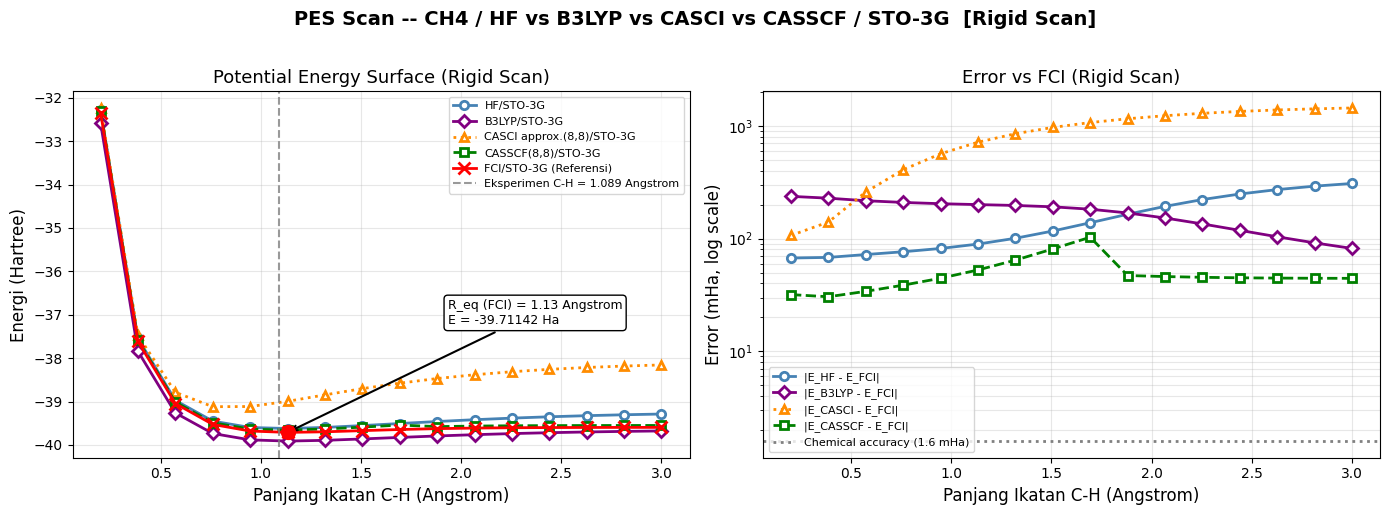

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Plot 1: PES --
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASCI,  '^:',  color='darkorange', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx.(8,8)/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(8,8)/STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI/STO-3G (Referensi)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq (FCI) = {R[idx_fci]:.2f} Angstrom\nE = {E_FCI[idx_fci]:.5f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]+0.8, E_FCI[idx_fci]+2.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=1.089, color='gray', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen C-H = 1.089 Angstrom')
ax1.set_xlabel('Panjang Ikatan C-H (Angstrom)', fontsize=12)
ax1.set_ylabel('Energi (Hartree)', fontsize=12)
ax1.set_title('Potential Energy Surface (Rigid Scan)', fontsize=13)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# -- Plot 2: Error vs FCI (dikonversi ke mHa) --
error_hf_mHa     = error_hf     * 1000
error_dft_mHa    = error_dft    * 1000
error_casci_mHa  = error_casci  * 1000
error_casscf_mHa = error_casscf * 1000
CA_mHa = CA * 1000  # 1.6 mHa

ax2.semilogy(R, error_hf_mHa,     'o-',  color='steelblue',  linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft_mHa,    'D-',  color='purple',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casci_mHa,  '^:',  color='darkorange', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI - E_FCI|')
ax2.semilogy(R, error_casscf_mHa, 's--', color='green',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.axhline(y=CA_mHa, color='gray', linestyle=':',
            linewidth=2, label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan C-H (Angstrom)', fontsize=12)
ax2.set_ylabel('Error (mHa, log scale)', fontsize=12)
ax2.set_title('Error vs FCI (Rigid Scan)', fontsize=13)
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('PES Scan -- CH4 / HF vs B3LYP vs CASCI vs CASSCF / STO-3G  [Rigid Scan]',
              fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PES_CH4_benchmark_SP.png', dpi=150, bbox_inches='tight')
plt.show()

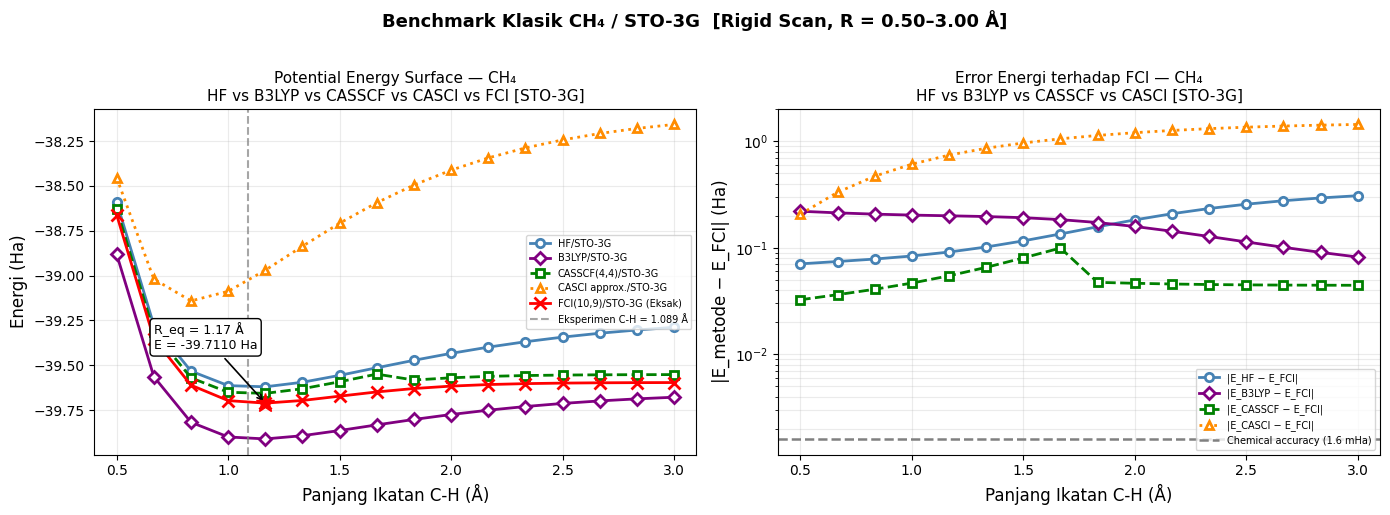

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data CH4 Range 0.50–3.00 Å, 16 titik ──
R = list(np.linspace(0.50, 3.00, 16))

E_HF = [-38.590753477611, -39.276666060660, -39.532617363640, -39.613309561248,
        -39.619934608547, -39.594583280949, -39.556175196474, -39.513857600150,
        -39.472186012913, -39.433482672605, -39.398876862728, -39.368750577144,
        -39.343012398230, -39.321316723946, -39.303220298253, -39.288258469079]

E_DFT = [-38.881485071917, -39.563480530371, -39.817725199412, -39.899580290894,
         -39.910562100912, -39.892519484148, -39.863680966380, -39.832283700154,
         -39.802004087261, -39.774477409474, -39.750383963337, -39.729861409066,
         -39.712727504120, -39.698636540532, -39.687207741963, -39.678060018491]

E_CASSCF = [-38.628820279594, -39.314672294710, -39.570184723838, -39.650386088465,
            -39.656553155152, -39.630776480821, -39.591957832144, -39.549235555453,
            -39.582255537758, -39.569721539045, -39.561815576783, -39.557162875256,
            -39.554538435502, -39.553091701964, -39.552304935046, -39.551882425184]

# CASCI approx: orbital HF (versi lama)
E_CASCI = [-38.454866950257, -39.019324588792, -39.141123843086, -39.087531704919,
           -38.969789907144, -38.836191346430, -38.707896273013, -38.593339948968,
           -38.494831847205, -38.412060819088, -38.343713704531, -38.288081795034,
           -38.243322039922, -38.207636253758, -38.179390691499, -38.157163790342]

# CASCI fixed: orbital CASSCF (dari CH4_CASCI_fixed.*.out)
E_CASCI_fixed = [-38.628820279594, -39.314753615463, -39.570156135764, -39.650386088465,
                 -39.656550312280, -39.630783358389, -39.591957832144, -39.549226972549,
                 -39.582258583321, -39.569721539045, -39.561814367331, -39.557163567790,
                 -39.554538435502, -39.553091491089, -39.552305049174, -39.551882425184]

E_FCI = [-38.661283721798, -39.350893073326, -39.610906058699, -39.696930396531,
         -39.711016490486, -39.696174728435, -39.672169701901, -39.648571140854,
         -39.629544229618, -39.616084021462, -39.607449208008, -39.602281543939,
         -39.599321692317, -39.597669082314, -39.596761508634, -39.596270730145]

# ── Error vs FCI ──
e_ref             = np.array(E_FCI)
error_hf          = np.abs(np.array(E_HF)          - e_ref)
error_dft         = np.abs(np.array(E_DFT)          - e_ref)
error_casscf      = np.abs(np.array(E_CASSCF)       - e_ref)
error_casci       = np.abs(np.array(E_CASCI)        - e_ref)
error_casci_fixed = np.abs(np.array(E_CASCI_fixed)  - e_ref)
CA = 0.0016

idx_fci = E_FCI.index(min(E_FCI))

# ── Plot Side-by-Side ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
xlim = (0.4, 3.1)

# ─────────────────────────────────────
# Panel Kiri: PES
# ─────────────────────────────────────
ax1.plot(R, E_HF,          'o-',  color='steelblue',  linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,         'D-',  color='purple',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF,      's--', color='green',      linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(4,4)/STO-3G')
ax1.plot(R, E_CASCI,       '^:',  color='darkorange', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx. (orb. HF)/STO-3G')
ax1.plot(R, E_CASCI_fixed, 'v-',  color='brown',      linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI fixed (orb. CASSCF)/STO-3G')
ax1.plot(R, E_FCI,         'x-',  color='red',        linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI(10,9)/STO-3G (Eksak)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'r*', markersize=14, zorder=5)
ax1.annotate(f'R_eq = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.4f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]-0.5, E_FCI[idx_fci]+0.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

ax1.axvline(x=1.089, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Eksperimen C-H = 1.089 Å')
ax1.set_xlim(xlim)
ax1.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax1.set_ylabel('Energi (Ha)', fontsize=12)
ax1.set_title('Potential Energy Surface — CH₄\nHF vs B3LYP vs CASSCF vs CASCI (2 versi) vs FCI [STO-3G]',
              fontsize=10)
ax1.legend(fontsize=7.0, loc='center right')
ax1.grid(True, alpha=0.25)

# ─────────────────────────────────────
# Panel Kanan: Error vs FCI
# ─────────────────────────────────────
ax2.semilogy(R, error_hf          + 1e-10, 'o-',  color='steelblue',  linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF − E_FCI|')
ax2.semilogy(R, error_dft         + 1e-10, 'D-',  color='purple',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP − E_FCI|')
ax2.semilogy(R, error_casscf      + 1e-10, 's--', color='green',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF − E_FCI|')
ax2.semilogy(R, error_casci       + 1e-10, '^:',  color='darkorange', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx. − E_FCI|')
ax2.semilogy(R, error_casci_fixed + 1e-10, 'v-',  color='brown',      linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI fixed − E_FCI|')
ax2.axhline(y=CA, color='gray', linestyle='--', linewidth=1.8,
            label='Chemical accuracy (1.6 mHa)')

ax2.set_xlim(xlim)
ax2.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax2.set_ylabel('|E_metode − E_FCI| (Ha)', fontsize=12)
ax2.set_title('Error Energi terhadap FCI — CH₄\nHF vs B3LYP vs CASSCF vs CASCI (2 versi) [STO-3G]',
              fontsize=10)
ax2.legend(fontsize=7.0, loc='lower right')
ax2.grid(True, alpha=0.25, which='both')

plt.suptitle('Benchmark Klasik CH₄ / STO-3G  [Rigid Scan, R = 0.50–3.00 Å]',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Benchmark_CH4_6Metode.png', dpi=150, bbox_inches='tight')
plt.show()